# Model

In [38]:
from acceptor_TI import Problem

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [39]:

data_path = "../../../acceptor_TI/data/"
file_name = "honeycomb.json"

problem = Problem(data_path=data_path, file_name=file_name)

In [ ]:
sub_1 = ["A", "B"]
sub_2 = ["B", "A"]
for sub_label, nn_label in zip(sub_1, sub_2):
    parser = getattr(problem.cell_parser.eigenvalues, sub_label).value
    parser["nn_hopping"][nn_label]["t_ss_sigma"] = -1
    parser["nn_hopping"][nn_label]["t_sp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_sigma"] = 1
    parser["nn_hopping"][nn_label]["t_pp_pi"] = -1.4
    # parser["SO_coupling"][sub_label]["lambda_pp"] = 0.3

In [41]:
location = "edge"
problem.setup(
    N_r = 10, # size of lattice in real space
    N_k = 200, # reciprocal space discretization
    location = location,
    BZ = "reduced"
)

Building Geometry...
Geometry - Done.
Building 'Edge' Hamiltonian...


'Edge' Hamiltonian - Done.


In [42]:
problem.model_options.solve_connectivity = False

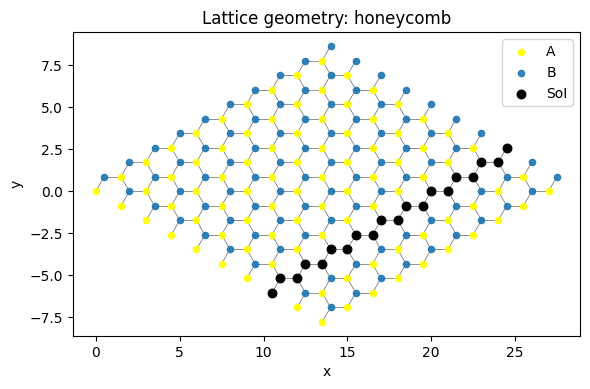

In [43]:
tb = problem.hamiltonian["edge"]["tight_binding"]
problem.geometry.plot_lattice(
    sites_of_interest=tb.sublattice_idxs
)

In [44]:
problem.geometry.T

array([ 1.5      , -0.8660254])

In [45]:
problem.run(
    acceptor=False,
    H_type="reciprocal_space"
)

Calculating 'Edge' eigenvalues...
'Edge' Eigenvalues - Done.


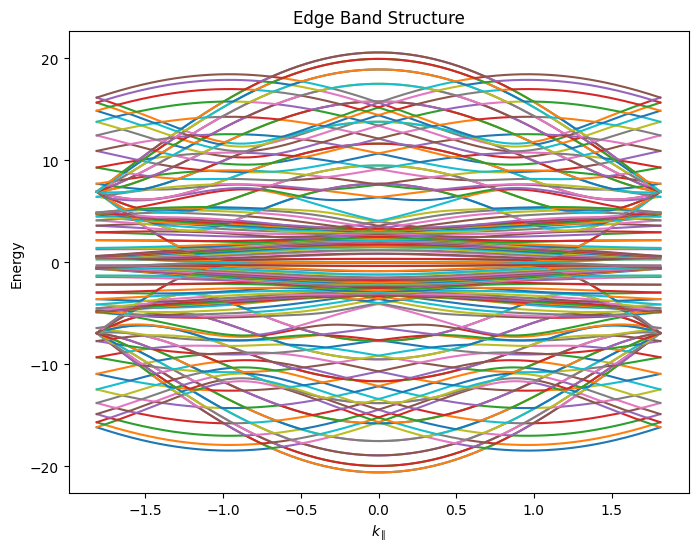

In [46]:
problem.plot(plot_type="dispersion", location=location)

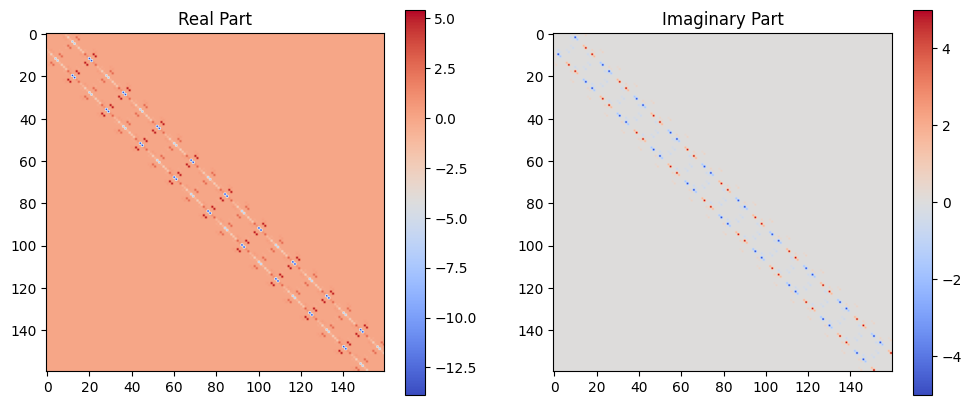

In [47]:
g = problem.geometry
k = g.k_edge[int(g.N_k/2) - 1]
H_k = tb._fourier_transform(g, k)
tb._visualise_matrix(H_k)